In [2]:
#importing
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import logging
logging.basicConfig(filename='model.log',
                    filemode='w',
                    format='%(asctime)s - %(message)s - %(levelname)s',
                    force=True
                    )

import kagglehub

# Download latest version
path = kagglehub.dataset_download("miadul/credit-card-fraud-detection-dataset")

print("Path to dataset files:", path)

100%|██████████| 111k/111k [00:00<00:00, 52.7MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/miadul/credit-card-fraud-detection-dataset/versions/1


In [3]:
path='/root/.cache/kagglehub/datasets/miadul/credit-card-fraud-detection-dataset/versions/1/credit_card_fraud_10k.csv'
df=pd.read_csv(path,sep=',')

In [6]:
df.sample(frac=1)

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
1907,1908,82.58,7,Clothing,0,0,63,0,42,0
8978,8979,185.79,0,Travel,0,0,72,4,68,0
288,289,60.77,3,Clothing,1,0,51,5,38,1
751,752,505.91,11,Clothing,0,0,29,1,52,0
3648,3649,163.55,10,Electronics,0,0,85,3,32,0
...,...,...,...,...,...,...,...,...,...,...
4760,4761,118.83,5,Grocery,0,0,51,2,64,0
3306,3307,83.89,19,Electronics,0,0,81,1,67,0
6850,6851,46.29,12,Electronics,0,0,94,2,60,0
4462,4463,1019.26,8,Travel,0,0,69,2,62,0


In [7]:
#dividing data into categorical and numerical
numerical_data=df.select_dtypes(exclude=object)
categorical_data=df.select_dtypes(include=object)


In [8]:
numerical_data


,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,0,0,66,3,40,0
1,2,541.82,3,1,0,87,1,64,0
2,3,237.01,17,0,0,49,1,61,0
3,4,164.33,4,0,1,72,3,34,0
4,5,30.53,15,0,0,79,0,44,0
...,...,...,...,...,...,...,...,...,...
9995,9996,350.91,22,0,0,99,4,37,0
9996,9997,410.04,5,0,0,70,3,25,0
9997,9998,527.75,21,0,0,44,2,45,0
9998,9999,91.20,2,0,0,38,0,37,0


In [9]:
categorical_data

,merchant_category
0,Electronics
1,Travel
2,Grocery
3,Grocery
4,Food
...,...
9995,Food
9996,Clothing
9997,Electronics
9998,Electronics


In [11]:
#performing eda
from collections import OrderedDict
stats=[]

for i in numerical_data:
  numerical_stats=OrderedDict({
      'feature':i,
      'mean':numerical_data[i].mean(),
      'median':numerical_data[i].median(),
      'std':numerical_data[i].std(),
      'mode':numerical_data[i].mode()[0],
      'min':numerical_data[i].min(),
      'max':numerical_data[i].max(),
      'kurtosis':numerical_data[i].kurtosis(),
      'skewness':numerical_data[i].skew(),
      'variance':numerical_data[i].var(), })

  stats.append(numerical_stats)
  report=pd.DataFrame(stats)
report

,feature,mean,median,std,mode,min,max,kurtosis,skewness,variance
0,transaction_id,5000.500000,5000.500,2886.895680,1.00,1.0,10000.00,-1.200000,0.000000,8.334167e+06
1,amount,175.949849,122.095,175.392827,0.04,0.0,1471.04,5.118220,1.919265,3.076264e+04
2,transaction_hour,11.593300,12.000,6.922708,14.00,0.0,23.00,-1.205681,-0.026581,4.792389e+01
3,foreign_transaction,0.097800,0.000,0.297059,0.00,0.0,1.00,5.336618,2.708422,8.824398e-02
4,location_mismatch,0.085700,0.000,0.279935,0.00,0.0,1.00,6.766327,2.960570,7.836335e-02
5,device_trust_score,61.798900,62.000,21.487053,45.00,25.0,99.00,-1.180000,0.011191,4.616934e+02
6,velocity_last_24h,2.008900,2.000,1.432559,1.00,0.0,9.00,0.445559,0.707884,2.052226e+00
7,cardholder_age,43.468700,44.000,14.979147,29.00,18.0,69.00,-1.197184,0.003868,2.243749e+02
8,is_fraud,0.015100,0.000,0.121957,0.00,0.0,1.00,61.271729,7.953582,1.487348e-02


In [12]:
logging.info('the data is distributed non-normally')

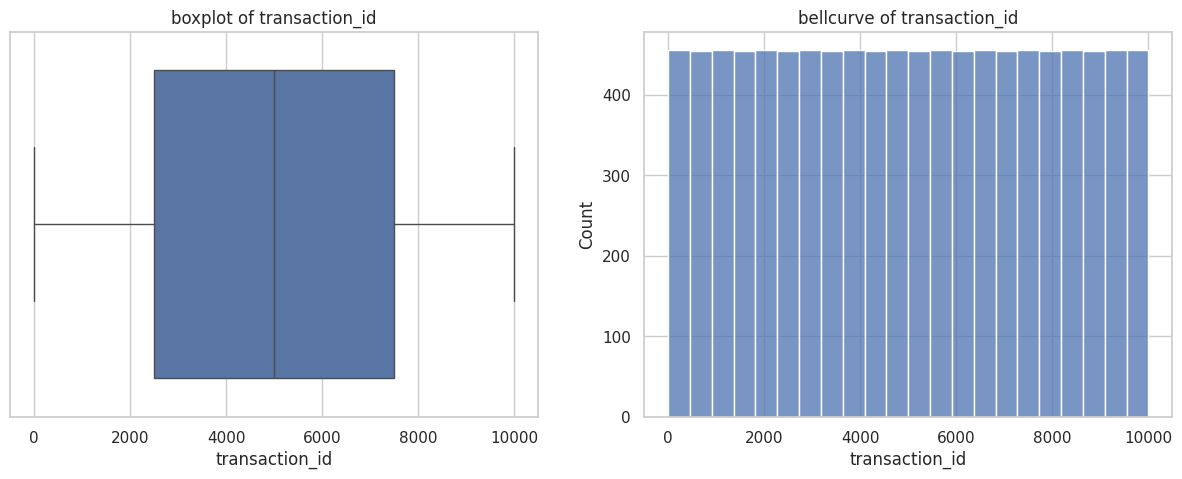

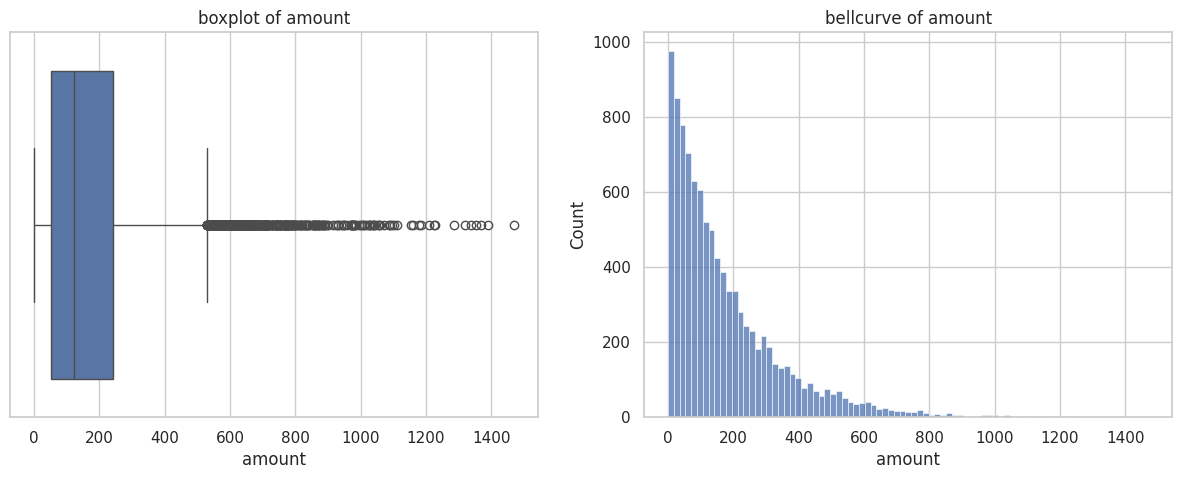

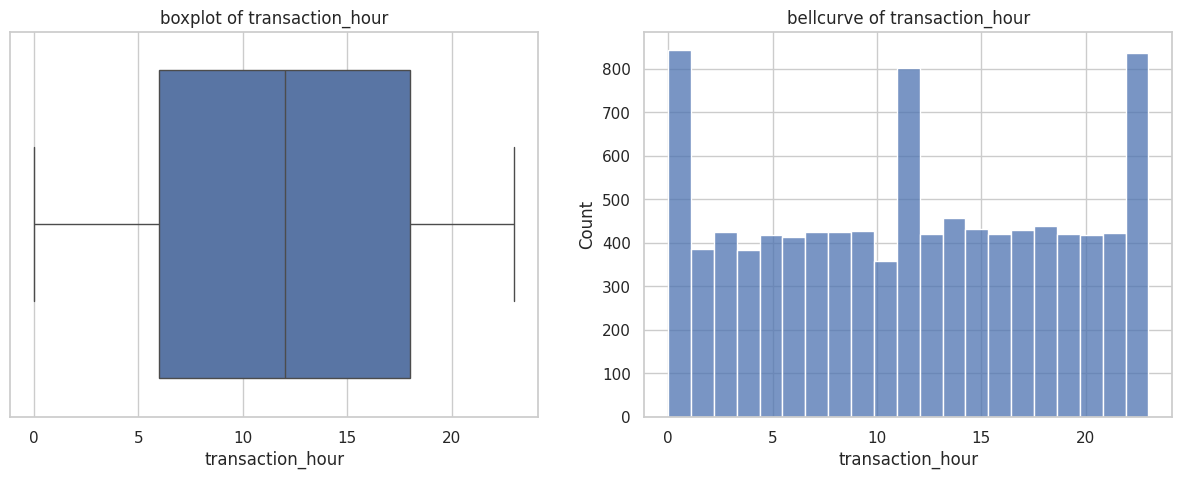

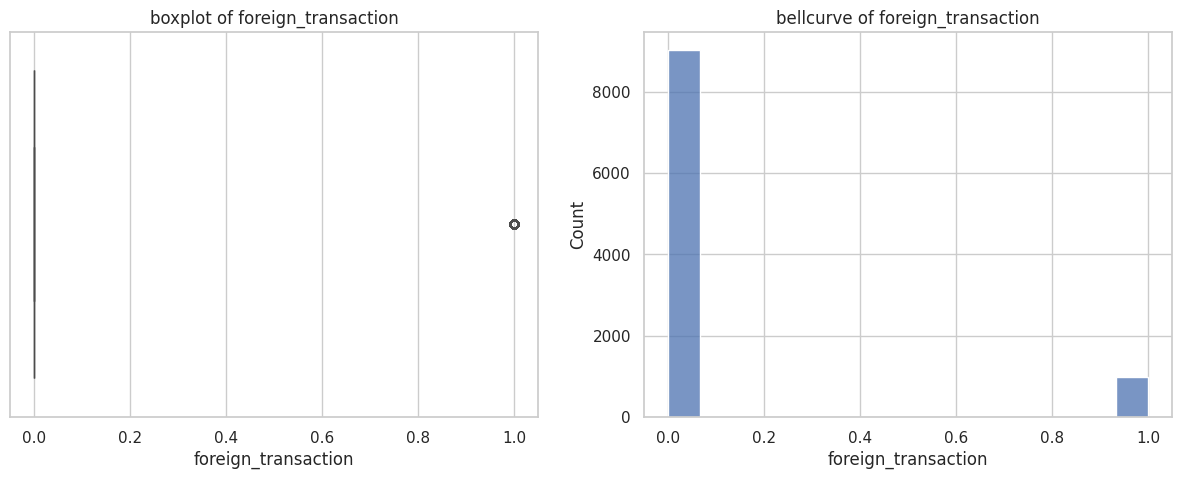

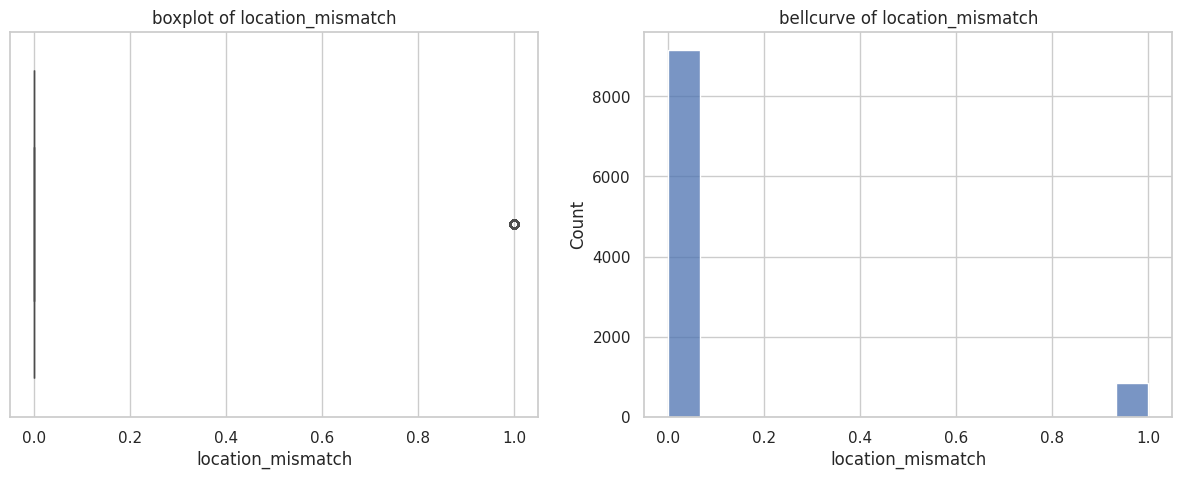

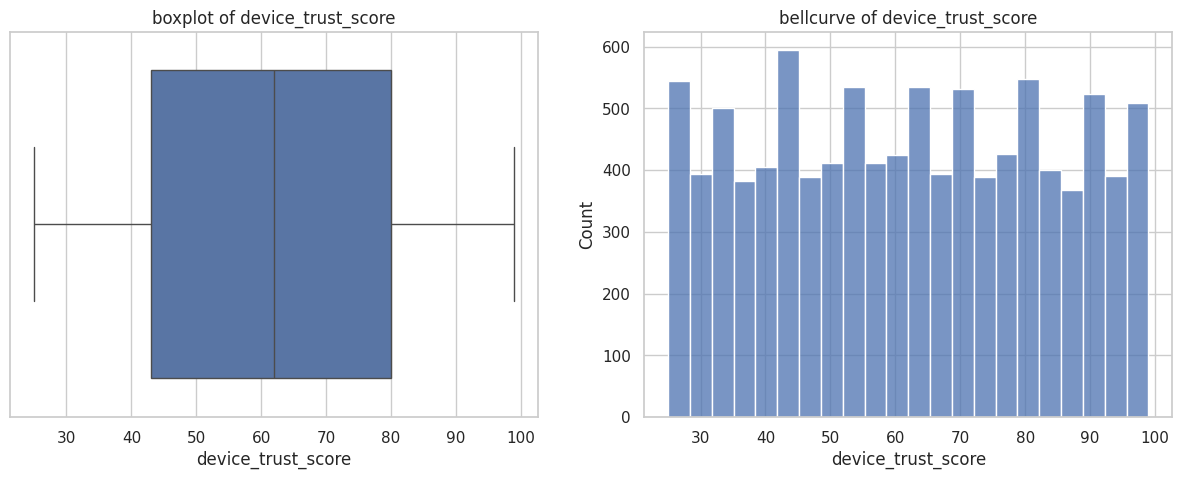

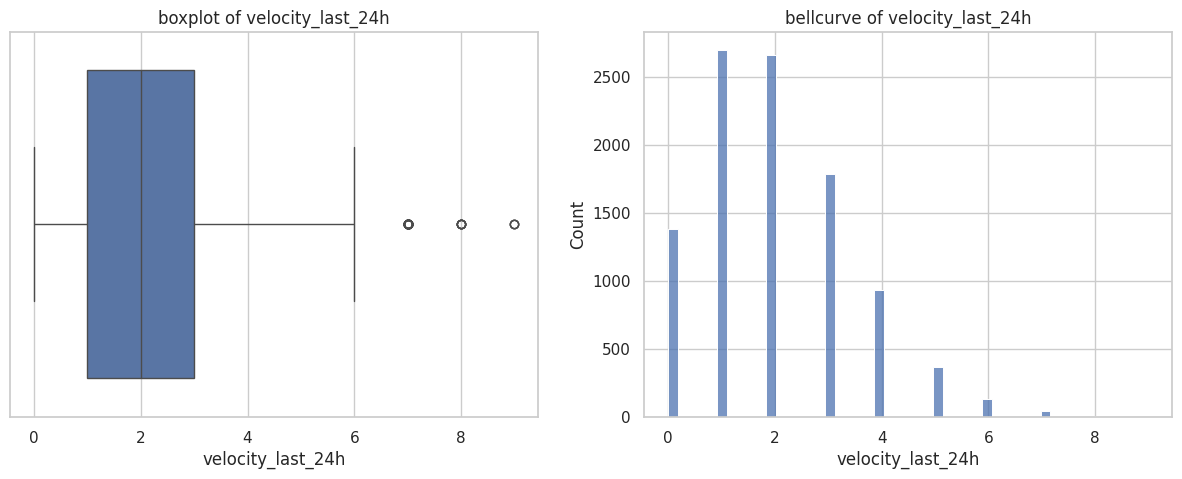

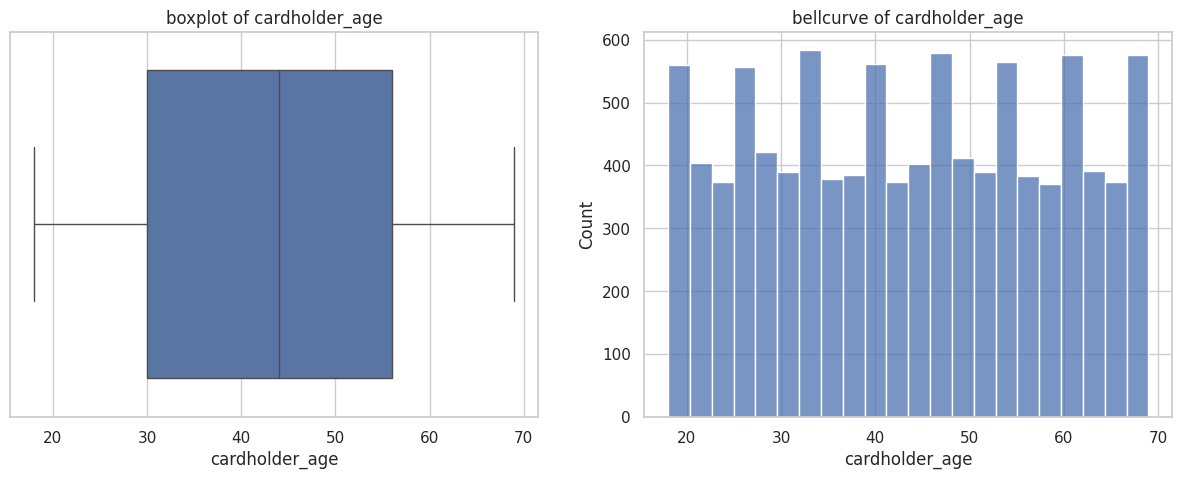

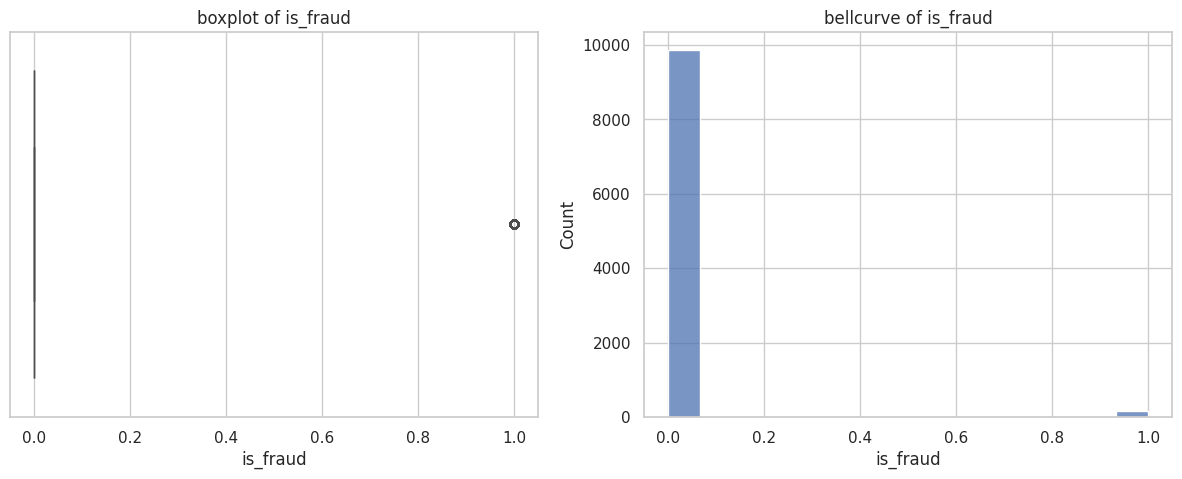

In [13]:
#check for outliers
sns.set(style='whitegrid')
for col in numerical_data.columns:
  plt.figure(figsize=(15,5))

  plt.subplot(1,2,1)
  sns.boxplot(x=df[col])
  plt.title(f'boxplot of {col}')

  plt.subplot(1,2,2)
  sns.histplot(x=df[col])
  plt.title(f'bellcurve of {col}')

  plt.show()


In [14]:
#checking for null
df.isnull().sum()



,0
transaction_id,0
amount,0
transaction_hour,0
merchant_category,0
foreign_transaction,0
location_mismatch,0
device_trust_score,0
velocity_last_24h,0
cardholder_age,0
is_fraud,0


In [15]:
#using labelencoder for merchant_category
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['merchant_category']=le.fit_transform(df['merchant_category'])


In [17]:
#checking if target column is balanced
df['is_fraud'].value_counts()

,count
is_fraud,
0,9849
1,151


In [21]:
#train test split
from sklearn.model_selection import train_test_split
x=df.drop('is_fraud',axis=1)
y=df['is_fraud']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=69)

#robustscaler
from sklearn.preprocessing import RobustScaler
rs=RobustScaler()
x_train=rs.fit_transform(x_train)
x_test=rs.transform(x_test)

In [22]:
#using smote to balance target
from imblearn.over_sampling import SMOTE
smote=SMOTE()
x=df.drop('is_fraud',axis=1)
y=df['is_fraud']
x_smote,y_smote=smote.fit_resample(x,y)

In [23]:
#using logistic regression
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)
from sklearn.metrics import accuracy_score,classification_report
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))


0.992
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      2962
           1       0.77      0.53      0.62        38

    accuracy                           0.99      3000
   macro avg       0.88      0.76      0.81      3000
weighted avg       0.99      0.99      0.99      3000

